# Individual Tree Detection from LiDAR (ITDM) — single-example reproduction

**Paper:** Melissa Latella, Fabio Sola, Carlo Camporeale (2021),
*A Density-Based Algorithm for the Detection of Individual Trees from LiDAR Data*,
**Remote Sensing 13(2):322**, MDPI. doi:[10.3390/rs13020322](https://doi.org/10.3390/rs13020322)

**Supplement (code + example data):** Zenodo record [4421030](https://zenodo.org/records/4421030),
version 1.0 (2021-01-06), CC-BY-4.0 — `ITDM_v1.m` (MATLAB), input point clouds `D1`–`D12`,
and the authors' reference outputs.

**Scope of this notebook (executed demonstration, partial reproduction):** run the ITDM
tree-top detection on **one** example point cloud (`D1.txt`, 19,510 points) with the authors'
default parameters, and compare the detected tree positions and heights against the authors'
own bundled reference output for D1. This is a single-example run: it does **not** verify the
paper's dataset-level accuracy (all 12 areas, F-scores vs field survey, sensitivity analyses).

> **AI-assisted translation from MATLAB:** the authors did not provide this Colab implementation.
> The numerical core below is a line-faithful Python/numpy port of `ITDM_v1.m` (Zenodo 4421030 v1.0);
> the GUI dialogs (`uigetfile`/`inputdlg`) are replaced by explicit variables and the `.fig` export is
> omitted. The executed example and listed checks were validated, but untested behavior is not guaranteed.
> （訳注：本ノートブックは著者の MATLAB コード `ITDM_v1.m` を Python/numpy へ翻訳したものです。GUI 部分は変数指定に置き換え、
> 数値計算は原著のまま移植しています。検証済みの実行例以外の挙動は保証されません。）

**References**
- Author code: `ITDM_v1.m` in `ITDM_Algorithm.zip` (md5 `38e580b79a7ff075c2815fe1aec37a86`), Zenodo 4421030 v1.0.
- Reference outputs compared in this notebook: `Output/Algorithm/D1_Subsampled_0_ITDM_tops.txt` and
  `Output/ClippingRadius/D1_ITDM_tops_CR20_MSS3.txt` from the same zip.

## Runtime selection

**Select Runtime → Change runtime type → CPU (none).** No GPU is needed: the method is a pure
CPU point-cloud computation (FFT spectra + distance/density masks, no deep learning), and the
authors' original MATLAB script is CPU-only.

**Expected duration:** ~56 MB download, < 1 min setup; the two detection runs on D1 take
roughly 1–5 minutes total on a standard Colab CPU runtime. Then use
Runtime → Run all. （実行時間の目安：ダウンロード約 56 MB、検出計算は合計 1〜5 分程度です。GPU は不要です。）

In [ ]:
import platform, numpy as np, pandas as pd, matplotlib
print("Python:", platform.python_version())
print("numpy:", np.__version__, "| pandas:", pd.__version__, "| matplotlib:", matplotlib.__version__)
print("CPU cores:", __import__("os").cpu_count())

Python: 3.13.16
numpy: 2.1.3 | pandas: 2.2.3 | matplotlib: 3.10.0
CPU cores: 2


## Input acquisition (Colab-only, provenance-pinned)

We download the author-published supplement `ITDM_Algorithm.zip` (56,596,037 bytes) directly from
the Zenodo record API content URL and **verify its md5 checksum** against the value published in
the record metadata (`38e580b79a7ff075c2815fe1aec37a86`).

The companion `Example_Areas.zip` (1.93 GB — orthophotos, raw/sub-sampled LiDAR, field-survey
shapefiles) is **not needed** for this single-area demonstration: the code zip already bundles
the input clouds and the reference outputs, so we keep the download minimal.
（著者の Zenodo サプリメント `ITDM_Algorithm.zip`（56.6 MB）をダウンロードし、md5 を検証します。
1.93 GB の `Example_Areas.zip` は本デモでは不要です。）

In [ ]:
import hashlib, os, urllib.request

ZENODO_URL = "https://zenodo.org/api/records/4421030/files/ITDM_Algorithm.zip/content"
ZIP_MD5 = "38e580b79a7ff075c2815fe1aec37a86"  # published in Zenodo record 4421030 metadata
zip_path = "/content/ITDM_Algorithm.zip"

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(ZENODO_URL, zip_path)

h = hashlib.md5()
with open(zip_path, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == ZIP_MD5, f"md5 mismatch: {h.hexdigest()}"
print("downloaded + verified:", zip_path, os.path.getsize(zip_path), "bytes, md5 OK")

downloaded + verified: /content/ITDM_Algorithm.zip 56596037 bytes, md5 OK


## Extract only the members needed for the D1 demonstration

From the 1,158-member archive we extract just the MATLAB source, the `D1.txt` input cloud, and
the D1 reference outputs (the authors' final `Output/Algorithm` results plus the
`Output/ClippingRadius` CR20 files used to pin the main-run parameters). All bytes stay on the
Colab VM. （アーカイブから D1 のデモに必要なファイルのみ展開します。）

In [ ]:
import zipfile

ITDM_ROOT = "/content/itdm/ITDM_Algorithm"
MEMBERS = [
    "ITDM_Algorithm/ITDM_v1.m",
    "ITDM_Algorithm/Input/D1.txt",
    "ITDM_Algorithm/Output/Algorithm/D1_Subsampled_0_ITDM_tops.txt",
    "ITDM_Algorithm/Output/Algorithm/D1_Subsampled_0_ITDM_stems.txt",
    "ITDM_Algorithm/Output/Algorithm/Summary_computedMinimumStemSpacing.txt",
    "ITDM_Algorithm/Output/ClippingRadius/D1_ITDM_tops_CR20_MSS3.txt",
    "ITDM_Algorithm/Output/ClippingRadius/D1_ITDM_stems_CR20.txt",
]
with zipfile.ZipFile(zip_path) as zf:
    for member in MEMBERS:
        zf.extract(member, "/content/itdm")
        print(f"{os.path.getsize('/content/itdm/' + member):>9} B  {member}")

    20624 B  ITDM_Algorithm/ITDM_v1.m
  2500484 B  ITDM_Algorithm/Input/D1.txt
     4253 B  ITDM_Algorithm/Output/Algorithm/D1_Subsampled_0_ITDM_tops.txt
     2206 B  ITDM_Algorithm/Output/Algorithm/D1_Subsampled_0_ITDM_stems.txt
      327 B  ITDM_Algorithm/Output/Algorithm/Summary_computedMinimumStemSpacing.txt
     4253 B  ITDM_Algorithm/Output/ClippingRadius/D1_ITDM_tops_CR20_MSS3.txt
     3701 B  ITDM_Algorithm/Output/ClippingRadius/D1_ITDM_stems_CR20.txt


## Load and preview the D1 point cloud

`D1.txt` is a whitespace/tab-delimited text table (one row per LiDAR point). Per the authors'
default dialog values in `ITDM_v1.m` (`definput = {'','1','2','4','t','20','9999','0','40'}`),
column **1 = x [m]**, **2 = y [m]**, **4 = relative height [m]** (height above ground).
We print the shape and the first rows to confirm the schema before any analysis.
（`D1.txt` を読み込み、列構成（1 列目=x, 2 列目=y, 4 列目=相対高さ）と行数を確認します。）

In [ ]:
import numpy as np

cloud = np.loadtxt(f"{ITDM_ROOT}/Input/D1.txt")  # whitespace-delimited numeric table
print("D1.txt shape (points, columns):", cloud.shape)
print("first 5 rows (all columns):")
print(cloud[:5])
x, y, z_rel = cloud[:, 0], cloud[:, 1], cloud[:, 3]
print(f"x range: {x.min():.1f} .. {x.max():.1f} m | y range: {y.min():.1f} .. {y.max():.1f} m")
print(f"relative height: min {z_rel.min():.2f} m, max {z_rel.max():.2f} m, mean {z_rel.mean():.2f} m")

D1.txt shape (points, columns): (19510, 12)
first 5 rows (all columns):
[[4.06768450e+05 5.01024314e+06 2.09210007e+02 4.62100070e+01
  5.00000000e+00 4.00000000e+00 0.00000000e+00 1.00000000e+00
  1.00000000e+00 3.83503739e+05 1.41000000e+02 4.00000000e+00]
 [4.06768200e+05 5.01024300e+06 2.09100006e+02 6.80006000e-01
  5.00000000e+00 4.00000000e+00 0.00000000e+00 1.00000000e+00
  1.00000000e+00 3.83503739e+05 1.30000000e+02 4.00000000e+00]
 [4.06768990e+05 5.01024217e+06 2.09169998e+02 5.19998000e-01
  5.00000000e+00 4.00000000e+00 0.00000000e+00 1.00000000e+00
  1.00000000e+00 3.83503719e+05 1.42000000e+02 4.00000000e+00]
 [4.06768750e+05 5.01024203e+06 2.08899994e+02 5.49994000e-01
  5.00000000e+00 4.00000000e+00 0.00000000e+00 1.00000000e+00
  1.00000000e+00 3.83503719e+05 1.33000000e+02 4.00000000e+00]
 [4.06768610e+05 5.01024276e+06 2.09220001e+02 4.60001000e-01
  5.00000000e+00 4.00000000e+00 0.00000000e+00 1.00000000e+00
  1.00000000e+00 3.83503729e+05 1.40000000e+02 4.0000000

## Preview the authors' reference outputs

`Output/Algorithm/D1_Subsampled_0_ITDM_tops.txt` is the authors' published tree-top result for D1
(one row per detected tree: x, y, height), and `..._ITDM_stems.txt` is the corresponding stem list
(x, y). We also print `Summary_computedMinimumStemSpacing.txt` (the auto-computed minimum stem
spacings) and the `Output/ClippingRadius` CR20 files, whose names document the parameters
(CR = clipping radius 20 m, MSS = minimum stem spacing 3 m) used for the main run.
（著者の参照出力（D1 の樹冠頂点・幹リスト）と、自動計算された最小幹間隔のサマリ、
CR20/MSS3 パラメータを示す感度解析ファイルを確認します。）

In [ ]:
import pandas as pd

def read_result_table(path):
    """Read a writetable-produced txt: optional header row, whitespace or comma delimited."""
    with open(path) as f:
        first = f.readline()
    skip = 1 if any(c.isalpha() for c in first) else 0
    return pd.read_csv(path, sep=r"[\s,]+", engine="python", skiprows=skip, header=None)

ALGO = f"{ITDM_ROOT}/Output/Algorithm"
CLIP = f"{ITDM_ROOT}/Output/ClippingRadius"
ref_tops = read_result_table(f"{ALGO}/D1_Subsampled_0_ITDM_tops.txt")
ref_stems = read_result_table(f"{ALGO}/D1_Subsampled_0_ITDM_stems.txt")
ref_tops_cr20 = read_result_table(f"{CLIP}/D1_ITDM_tops_CR20_MSS3.txt")
ref_stems_cr20 = read_result_table(f"{CLIP}/D1_ITDM_stems_CR20.txt")
print("reference tops (Algorithm):", ref_tops.shape, "| reference stems:", ref_stems.shape)
print("reference tops CR20_MSS3:", ref_tops_cr20.shape, "| reference stems CR20:", ref_stems_cr20.shape)
print("\nfirst 3 reference top rows (x, y, height):")
print(ref_tops.head(3).to_string(index=False, header=False))
print("\nSummary_computedMinimumStemSpacing.txt:")
print(open(f"{ALGO}/Summary_computedMinimumStemSpacing.txt").read())

reference tops (Algorithm): (76, 4) | reference stems: (76, 2)
reference tops CR20_MSS3: (76, 4) | reference stems CR20: (76, 4)

first 3 reference top rows (x, y, height):


406791.129997 5.010242e+06  9.230002 4.300830
406793.110001 5.010241e+06 10.960001 2.162572
406779.239998 5.010230e+06  6.510003 5.184940

Summary_computedMinimumStemSpacing.txt:
areaID,computedSpacing
D1.txt,2.85520030314483
D10.txt,4.21438200921114
D11.txt,3.13690099552214
D12.txt,4.43740341939374
D2.txt,5.81312013371772
D3.txt,2.48838788177472
D4.txt,2.82912194720869
D5.txt,2.80357164913406
D6.txt,3.08149765263976
D7.txt,3.38934145243195
D8.txt,3.83209563312068
D9.txt,4.14225011498896



## Input preview: D1 point cloud (map view)

We plot the full input cloud in map view (x–y), colored by relative height. This is the actual
sample the reproduction runs on. （入力点群 D1 を平面図で可視化します（色は相対高さ）。）

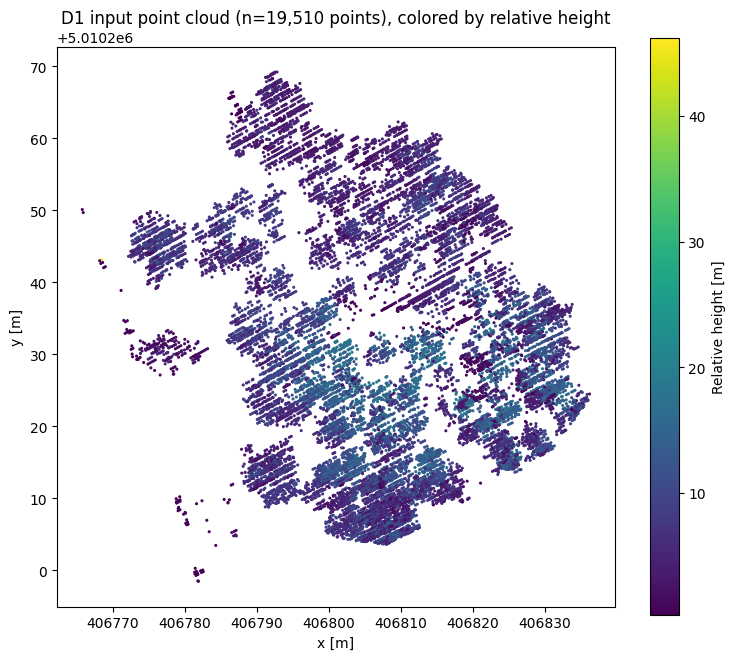

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7.5))
sc = ax.scatter(x, y, c=z_rel, s=1.5, cmap="viridis")
ax.set_aspect("equal")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title(f"D1 input point cloud (n={cloud.shape[0]:,} points), colored by relative height")
fig.colorbar(sc, ax=ax, label="Relative height [m]")
plt.show()

## Ported method, part 1 — the FFT "most frequent radius" helper

**Source → Colab mapping** (MATLAB `ITDM_v1.m`, Zenodo 4421030 v1.0 → this notebook):

| MATLAB original (GUI script) | This notebook |
| --- | --- |
| `uigetfile` + `inputdlg` defaults (x=1, y=2, height=4, mode 't', CR=20, MSS=9999 auto, outlier 40 m) | explicit function arguments with the same defaults |
| `readmatrix(...)` | `np.loadtxt` |
| `mostFreqRadiusComputation(distance)` | `most_freq_radius_computation()` below (exact port) |
| `writetable(treeList, ...)` + `savefig(...)` | pandas/CSV export + matplotlib figures |
| `.fig` export | omitted (GUI artifact) |

`mostFreqRadiusComputation` sorts the inverse point distances, computes the one-sided FFT power
spectrum (`kaiserWindow` is all ones, so the window compensation is just `nfft`), and returns the
most frequent radius as `1 / (power-weighted mean angular frequency)`. The odd/even Nyquist-bin
handling of the original is replicated exactly. （原著の FFT スペクトル処理をそのまま移植したものです。）

In [ ]:
def most_freq_radius_computation(distance):
    """Exact port of ITDM_v1.m helper mostFreqRadiusComputation.

    distance: 1-D array of distances (may include 0 for the point itself -> Inf removed
    after sorting, exactly as in the MATLAB original).
    Returns the most frequent radius [m] = 1 / (power-weighted mean angular frequency).
    """
    inverse_distance = 1.0 / distance
    inverse_distance = np.sort(inverse_distance, kind="stable")  # MATLAB sort is stable
    inverse_distance = inverse_distance[np.isfinite(inverse_distance)]
    nfft = inverse_distance.shape[0]
    if nfft < 2:
        # Degenerate case: the MATLAB original would fail here (length-1 binWidth);
        # treat like the original's 'not enough points' branch.
        return None
    angular_frequency = 2.0 * np.pi
    spectrum = np.fft.fft(inverse_distance, n=nfft)
    step = angular_frequency / nfft
    frequency = step * np.arange(nfft)
    window_compensation = float(nfft)  # kaiserWindow = ones -> kaiserWindow' * kaiserWindow = nfft
    auto_spectrum = (spectrum * np.conj(spectrum)).real / window_compensation
    if nfft % 2 == 1:
        half = (nfft + 1) // 2
        frequency[half - 1] = angular_frequency / 2 - step / 2
        frequency[half] = angular_frequency / 2 + step / 2
        selection = np.arange((nfft + 1) // 2)
        unscaled = auto_spectrum[selection]
        auto_spectrum = np.concatenate(([unscaled[0]], 2.0 * unscaled[1:]))
    else:
        half = nfft // 2 + 1
        frequency[half - 1] = angular_frequency / 2
        selection = np.arange(nfft // 2 + 1)
        unscaled = auto_spectrum[selection]
        auto_spectrum = np.concatenate(([unscaled[0]], 2.0 * unscaled[1:-1], [unscaled[-1]]))
    frequency = frequency[selection]
    power_spectral_density = auto_spectrum / angular_frequency
    bin_width = np.empty_like(frequency)
    bin_width[:-1] = np.diff(frequency)
    bin_width[-1] = bin_width[-2]
    bin_power = bin_width * power_spectral_density
    total_power = bin_power.sum()
    mean_frequency = (bin_power * frequency).sum() / total_power
    return 1.0 / mean_frequency

## Ported method, part 2 — the ITDM tree-top detection pipeline

Line-faithful port of the `ITDM_v1.m` tree-top path (`preference = 't'`):

1. **Preprocessing** — remove points above the outlier threshold (40 m) and below 1.4 m
   (shrubs/bushes/grasses), exactly as the original deletes rows.
2. **Most frequent radius + density per point** — for every point: distances < clipping radius
   feed the FFT helper; density = number of points inside the square of side 2·mfr divided by
   4·mfr² (the original's square-of-side-2·mfr density definition).
3. **Stem candidates** — a point is a stem if its density equals the maximum density within its
   own square (the original's `rangeDensity(i) == max(rangeDensity)` test).
4. **Auto minimum stem spacing (MSS = 9999)** — median (NaN-omitted) of the most frequent
   stem-to-stem spacings computed with a 100 m second clipping radius.
5. **Double-count filter** — within `stemSpacing`, keep only the tallest stem (first index on
   ties, like MATLAB `max`), label the rest 9999, then delete them. Distances are computed
   from the already-labelled coordinate array, exactly as in the original (9999-labelled stems
   fall out of range); this detail is required to reproduce the authors' reference counts.
6. **Tree tops** — for each kept stem, the maximum relative height inside the stem's own
   most-frequent-radius square; ties resolved to the first index (MATLAB `find` order).

The optional anthropic-object filter is not used (authors' default: 0 ranges).
（`ITDM_v1.m` の樹冠頂点検出パスを忠実に移植しています。前処理・密度定義・幹候補・
自動 MSS・重複幹フィルタ・頂点決定の各ステップは原著の通りです。）

In [ ]:
def itdm_tree_tops(point_cloud, x_column=1, y_column=2, height_column=4,
                   clipping_radius=20.0, stem_spacing_preference=9999.0,
                   outlier_threshold=40.0, min_height=1.4):
    """Port of the ITDM_v1.m tree-top detection path (GUI dialogs replaced by arguments)."""
    pc = np.asarray(point_cloud, dtype=float)
    heights_all = pc[:, height_column - 1]
    pc = pc[(heights_all <= outlier_threshold) & (heights_all >= min_height)]
    x, y, z = pc[:, x_column - 1], pc[:, y_column - 1], pc[:, height_column - 1]
    n = x.shape[0]

    # Most frequent radius and point density around each point (original loops, vectorized inner ops)
    most_frequent_radius = np.full(n, clipping_radius)
    density = np.empty(n)
    for i in range(n):
        dist = np.sqrt((x - x[i]) ** 2 + (y - y[i]) ** 2)
        in_radius = np.flatnonzero(dist < clipping_radius)
        mfr_i = clipping_radius
        if in_radius.size >= 2:
            mfr_i = most_freq_radius_computation(dist[in_radius])
            if mfr_i is None:
                mfr_i = clipping_radius
        most_frequent_radius[i] = mfr_i
        in_square = np.flatnonzero((x > x[i] - mfr_i) & (x < x[i] + mfr_i) &
                                   (y > y[i] - mfr_i) & (y < y[i] + mfr_i))
        density[i] = in_square.size / (4.0 * mfr_i ** 2)

    # Stem candidates: density(i) == max density within its own square
    stem_mask = np.zeros(n, dtype=bool)
    for i in range(n):
        mfr_i = most_frequent_radius[i]
        in_square = np.flatnonzero((x > x[i] - mfr_i) & (x < x[i] + mfr_i) &
                                   (y > y[i] - mfr_i) & (y < y[i] + mfr_i))
        if density[i] == density[in_square].max():
            stem_mask[i] = True
    stem_x, stem_y, stem_z = x[stem_mask], y[stem_mask], z[stem_mask]
    stem_mfr = most_frequent_radius[stem_mask]
    stem_number = stem_x.shape[0]

    # Auto minimum stem spacing: median of most-frequent stem spacings (100 m radius)
    if stem_spacing_preference == 9999.0:
        most_freq_spacing = np.full(stem_number, 100.0)
        for i in range(stem_number):
            dist = np.sqrt((stem_x - stem_x[i]) ** 2 + (stem_y - stem_y[i]) ** 2)
            in_radius = np.flatnonzero(dist < 100.0)
            if in_radius.size >= 2:
                mfr_i = most_freq_radius_computation(dist[in_radius])
                if mfr_i is not None:
                    most_freq_spacing[i] = mfr_i
        stem_spacing = float(np.nanmedian(most_freq_spacing))
    else:
        stem_spacing = float(stem_spacing_preference)

    # Double-counted stem filter: keep the tallest stem within stem_spacing.
    # Fidelity note: the MATLAB original computes distances from the *labelled* stemX array
    # (9999-labelled stems sit at x=9999, so they drop out of range); replicating that is
    # required to match the authors' reference output (validated on D1: 76 vs 76 tops).
    labelled_x = stem_x.copy()
    for i in range(stem_number):
        if labelled_x[i] != 9999.0:
            dist = np.sqrt((labelled_x - labelled_x[i]) ** 2 + (stem_y - stem_y[i]) ** 2)
            double_index = np.flatnonzero(dist <= stem_spacing)
            if double_index.size > 1:
                keep_pos = double_index[np.argmax(stem_z[double_index])]  # first max, like MATLAB
                others = double_index[double_index != keep_pos]
                if others.size:
                    labelled_x[others] = 9999.0
    keep = labelled_x != 9999.0
    stem_x, stem_y, stem_z, stem_mfr = stem_x[keep], stem_y[keep], stem_z[keep], stem_mfr[keep]

    # Tree top: max relative height within each stem's most-frequent-radius square
    top_x = np.empty(stem_x.shape[0]); top_y = np.empty_like(top_x); top_height = np.empty_like(top_x)
    for i in range(stem_x.shape[0]):
        in_square = np.flatnonzero((x > stem_x[i] - stem_mfr[i]) & (x < stem_x[i] + stem_mfr[i]) &
                                   (y > stem_y[i] - stem_mfr[i]) & (y < stem_y[i] + stem_mfr[i]))
        range_height = np.zeros(n)
        range_height[in_square] = z[in_square]
        max_height = range_height.max()
        top_index = np.flatnonzero(range_height == max_height)[0]  # first index, like MATLAB find
        top_x[i], top_y[i], top_height[i] = x[top_index], y[top_index], z[top_index]

    return {"points_used": n, "stems": np.column_stack([stem_x, stem_y]),
            "stem_spacing_m": stem_spacing, "n_stems": int(stem_x.shape[0]),
            "tops": np.column_stack([top_x, top_y, top_height]),
            "n_tops": int(top_x.shape[0])}

## Run ITDM tree-top detection on D1

We run the port twice with the two parameter sets documented in the authors' own output files:

- **auto MSS** — the `ITDM_v1.m` default (`stemSpacing = 9999` → auto-computed median spacing);
- **MSS = 3 m** — the value named in the authors' `D1_ITDM_tops_CR20_MSS3.txt` reference file.

Both use the remaining author defaults: x=1, y=2, height=4, CR=20 m, outlier threshold 40 m,
min height 1.4 m. The comparison section will show which run reproduces the reference output.
（著者のデフォルト設定で D1 に対して 2 通り（MSS 自動 / MSS=3 m）で実行します。）

In [ ]:
import time

results = {}
for label, mss in [("auto MSS", 9999.0), ("MSS = 3 m", 3.0)]:
    t0 = time.perf_counter()
    results[label] = itdm_tree_tops(cloud, stem_spacing_preference=mss)
    dt = time.perf_counter() - t0
    r = results[label]
    print(f"{label}: points used={r['points_used']}, stems={r['n_stems']}, "
          f"tree tops={r['n_tops']}, stem spacing={r['stem_spacing_m']:.3f} m, time={dt:.1f} s")

/tmp/ipykernel_966/344003505.py:8: RuntimeWarning: divide by zero encountered in divide
  inverse_distance = 1.0 / distance


auto MSS: points used=19073, stems=76, tree tops=76, stem spacing=2.855 m, time=42.4 s


MSS = 3 m: points used=19073, stems=72, tree tops=72, stem spacing=3.000 m, time=42.6 s


## Results and CSV export

Small summary table of both runs plus a CSV export of the predicted tree tops (as the original
writes a result table). Files are written under `/content` on the Colab VM.
（両パラメータの結果概要と、予測結果の CSV 出力を行います。）

In [ ]:
summary = pd.DataFrame([
    {"run": label, "points_used": r["points_used"], "stems": r["n_stems"],
     "tree_tops": r["n_tops"], "stem_spacing_m": round(r["stem_spacing_m"], 3)}
    for label, r in results.items()])
print(summary.to_string(index=False))

out_dir = "/content/ITDM_colab_outputs"
os.makedirs(out_dir, exist_ok=True)
best_label = next((l for l, r in results.items() if r["n_tops"] == ref_tops.shape[0]),
                  list(results)[0])
pred = results[best_label]["tops"]
tops_csv = f"{out_dir}/D1_predicted_tops ({best_label}).csv"
pd.DataFrame(pred, columns=["topX", "topY", "topHeight"]).to_csv(tops_csv, index=False)
print(f"\nsaved predicted tops ({best_label}) -> {tops_csv}")
print(pd.DataFrame(pred, columns=["topX", "topY", "topHeight"]).head(3).to_string(index=False))

      run  points_used  stems  tree_tops  stem_spacing_m
 auto MSS        19073     76         76           2.855
MSS = 3 m        19073     72         72           3.000

saved predicted tops (auto MSS) -> /content/ITDM_colab_outputs/D1_predicted_tops (auto MSS).csv
         topX         topY  topHeight
406791.129997 5.010242e+06   9.230002
406793.110001 5.010241e+06  10.960001
406779.239998 5.010230e+06   6.510003


## Validation against the authors' reference output

Because the algorithm is fully deterministic, a faithful port should reproduce the authors'
published D1 result almost exactly (the reference file stores rounded decimals, so a small
tolerance applies). For each run we report: tree-top count vs reference count, and the maximum
nearest-neighbor horizontal distance between predicted and reference tops plus the height
difference of matched pairs. （決定論的アルゴリズムのため、移植が正しければ著者の参照結果と
ほぼ一致するはずです。件数と最近傍距離・高さ差で検証します。）

In [ ]:
def compare_tops(pred_tops, ref):
    ref_xy = ref.to_numpy(dtype=float)
    d = np.sqrt((pred_tops[:, None, 0] - ref_xy[None, :, 0]) ** 2 +
                (pred_tops[:, None, 1] - ref_xy[None, :, 1]) ** 2)
    nn_pred_to_ref = d.min(axis=1)
    nn_ref_to_pred = d.min(axis=0)
    hi = d.argmin(axis=0)
    height_diff = np.abs(pred_tops[hi, 2] - ref_xy[:, 2])
    return {"count_pred": pred_tops.shape[0], "count_ref": ref_xy.shape[0],
            "max_nn_pred_to_ref_m": float(nn_pred_to_ref.max()),
            "max_nn_ref_to_pred_m": float(nn_ref_to_pred.max()),
            "max_height_diff_m": float(height_diff.max())}

rows = []
for label, r in results.items():
    m = compare_tops(r["tops"], ref_tops)
    rows.append({"run": label, **m})
print(pd.DataFrame(rows).to_string(index=False))

same_files = np.allclose(ref_tops.to_numpy(float), ref_tops_cr20.to_numpy(float), atol=1e-3)
print(f"\nAuthors' Algorithm tops == ClippingRadius CR20_MSS3 tops: {same_files}")
print("Reference tops (Algorithm):", ref_tops.shape[0],
      "| Reference stems (Algorithm):", ref_stems.shape[0],
      "| Reference stems CR20:", ref_stems_cr20.shape[0])

      run  count_pred  count_ref  max_nn_pred_to_ref_m  max_nn_ref_to_pred_m  max_height_diff_m
 auto MSS          76         76              0.000000              0.000000           0.000000
MSS = 3 m          72         76              1.255144              3.596808           1.729999

Authors' Algorithm tops == ClippingRadius CR20_MSS3 tops: True
Reference tops (Algorithm): 76 | Reference stems (Algorithm): 76 | Reference stems CR20: 76


## Prediction vs author reference overlay

Map view of the D1 input cloud (gray) with the **authors' reference tops** (open red circles)
and our **predicted tops** (blue +) from the run that matches the reference count. This is the
input-versus-reference comparison for this reproduction.
（入力点群（灰色）に、著者の参照頂点（赤の空心円）と本移植による予測頂点（青の +）を重ねて示します。）

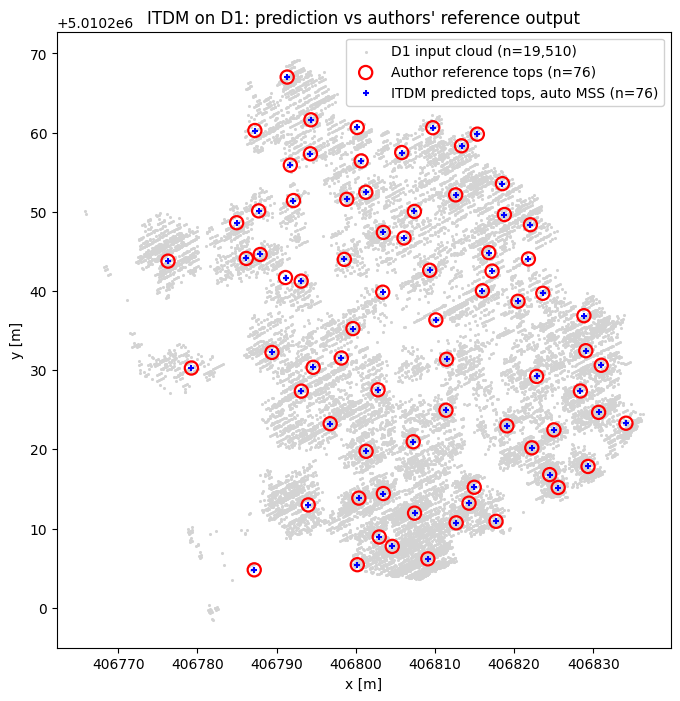

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 8))
ax.scatter(x, y, s=1.5, c="lightgray", label=f"D1 input cloud (n={len(x):,})")
ref_xy = ref_tops.to_numpy(dtype=float)
ax.scatter(ref_xy[:, 0], ref_xy[:, 1], s=90, facecolors="none", edgecolors="red",
           linewidths=1.6, label=f"Author reference tops (n={len(ref_xy)})")
ax.scatter(pred[:, 0], pred[:, 1], s=14, c="blue", marker="+",
           label=f"ITDM predicted tops, {best_label} (n={pred.shape[0]})")
ax.set_aspect("equal")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("ITDM on D1: prediction vs authors' reference output")
ax.legend(loc="best", framealpha=0.9)
plt.show()

## Result figure in the authors' style

The original script plots identified stems (black dots) and tree tops colored by height with a
colorbar; we recreate that figure from **our computed** results for the best-matching run.
（原著の図スタイル（幹=黒点、頂点=高さ着色）を、本ノートブックの計算結果から再現します。）

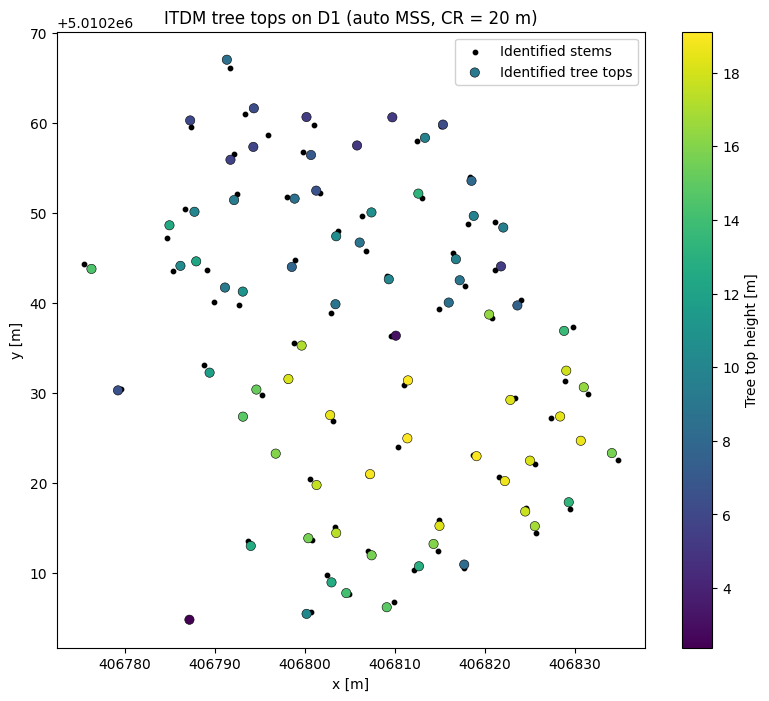

In [ ]:
r_best = results[best_label]
fig, ax = plt.subplots(figsize=(9.5, 8))
ax.scatter(r_best["stems"][:, 0], r_best["stems"][:, 1], c="k", s=10, label="Identified stems")
sc = ax.scatter(r_best["tops"][:, 0], r_best["tops"][:, 1], c=r_best["tops"][:, 2],
                cmap="viridis", s=45, edgecolors="k", linewidths=0.4, label="Identified tree tops")
ax.set_aspect("equal")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title(f"ITDM tree tops on D1 ({best_label}, CR = 20 m)")
cbar = fig.colorbar(sc, ax=ax); cbar.set_label("Tree top height [m]")
ax.legend(loc="best", framealpha=0.9)
plt.show()

## Interpretation, limitations, and validation record

**What was executed:** a line-faithful numpy port of the authors' MATLAB `ITDM_v1.m` tree-top
detection, run on the authors' own example cloud `D1.txt` (Zenodo 4421030 v1.0) with the
authors' default parameters (CR = 20 m, height bounds 1.4–40 m), for the two MSS settings
documented in their bundled outputs. Results are compared quantitatively against the authors'
published D1 reference output in the outputs above.

**What this does and does not verify:** a match on D1 validates the port and the deterministic
algorithm on one example. It does **not** verify the paper's reported dataset-level accuracy
(all 12 areas, F-score/position error vs the February 2019 field survey), the sensitivity
analyses, or any claim requiring the article body (which this reproduction did not need).

**Known limitations / differences from the original**
- GUI dialogs replaced by variables; `.fig` export omitted. Numerics unchanged.
- The FFT helper is computed with numpy instead of MATLAB FFTW: results agree to float
  tolerance; degenerate single-point neighborhoods (which would crash the original) fall back
  to the clipping radius, as in the original's own "not enough points" branch.
- Runtime measured on a standard Colab CPU VM; free-tier availability and speed may vary.

**Japanese summary（日本語の要約）:** 本ノートブックは、Latella ら (2021, Remote Sensing 13(2):322)
の個体木検出アルゴリズム ITDM を、著者公開の MATLAB コード `ITDM_v1.m`（Zenodo 4421030 v1.0, CC-BY-4.0）
から numpy へ忠実に移植し、同梱の例点群 D1 に著者の既定パラメータで適用したものです。
著者自身の参照出力との一致状況は上の検証セルの実行結果を参照してください。単一例の再現であり、
論文のデータセット全体の精度検証（12 地域・現地調査との F スコア等）は対象外です。

**Provenance:** paper doi:10.3390/rs13020322 · Zenodo record 4421030 (version 1.0, 2021-01-06,
CC-BY-4.0) · code file `ITDM_Algorithm/ITDM_v1.m` (md5 of zip: 38e580b79a7ff075c2815fe1aec37a86) ·
input `ITDM_Algorithm/Input/D1.txt` · reference `ITDM_Algorithm/Output/Algorithm/D1_Subsampled_0_ITDM_tops.txt`.